# S&P 500 Beta Analysis

This notebook estimates the **market beta** of every S&P 500 stock by regressing each stock's monthly returns against the S&P 500 index (via the SPY ETF).

---

### 📐 What is Beta?

Beta (β) is the slope of a simple linear regression: **Stock Return ~ SPY Return**.
It measures how sensitive a stock is to overall market movements.

| Beta | Interpretation | Typical sectors |
|------|---------------|-----------------|
| > 1 | More volatile than the market — amplifies gains **and** losses | Tech, Consumer Discretionary |
| = 1 | Moves in line with the market | — |
| 0 – 1 | Less volatile — defensive | Utilities, Healthcare |
| < 0 | Moves **opposite** to the market (rare) | Gold miners, some inverse ETFs |

> 💡 **Why does beta matter?** In the Capital Asset Pricing Model (CAPM), beta is the key risk measure. Higher-beta stocks demand a higher expected return as compensation for taking on more market risk.

---

### 🗺️ Workflow
| Step | What we do |
|------|------------|
| 1 | Import libraries |
| 2 | Scrape current S&P 500 constituents from Wikipedia |
| 3 | Download 5 years of adjusted close prices from Yahoo Finance |
| 4 | Convert daily prices → monthly returns |
| 5 | Define a regression function (alpha, beta, R², residual SE) |
| 6 | Run OLS for all 500+ stocks in one `.apply()` call |
| 7 | Visualise beta distributions by GICS sector (boxplot) |
| 8 | Summary statistics by sector |
| 9 | Most and least volatile individual stocks |
| 10 | Full beta histogram across the index |


## 1. Import Libraries

A quick guide to each library used in this notebook:

| Library | Role |
|---------|------|
| `requests` | Sends HTTP requests — used to fetch the Wikipedia page |
| `BeautifulSoup` | Parses the raw HTML into something Python can navigate |
| `pandas` | Core data manipulation: DataFrames, resampling, groupby |
| `datetime` | Creates date objects for defining our 5-year download window |
| `yfinance` | Unofficial Yahoo Finance wrapper — downloads historical price data |
| `numpy` | Fast numerical operations (sqrt, NaN handling) |
| `matplotlib` | Base plotting engine |
| `seaborn` | Higher-level statistical charts built on top of matplotlib |
| `statsmodels` | OLS regression with R-style formula syntax |
| `time` | Measures how long the 500+ regressions take |
| `io.StringIO` | Wraps an HTML string so `pd.read_html()` can parse it |


In [4]:
# ── Web scraping ─────────────────────────────────────────────────────────────
import requests                        # HTTP requests -- acts like a browser fetching a web page
from bs4 import BeautifulSoup          # HTML parser -- turns raw HTML into a navigable structure

# ── Data manipulation ─────────────────────────────────────────────────────────
import pandas as pd                    # DataFrames -- the core data manipulation tool
from datetime import date              # Date objects for defining our time window
from io import StringIO                # Wraps an HTML string so pd.read_html() can consume it

# ── Finance data ──────────────────────────────────────────────────────────────
import yfinance as yf                  # Yahoo Finance API wrapper for historical price data

# ── Numerical & statistical ───────────────────────────────────────────────────
import numpy as np                     # Numerical operations (sqrt, nan handling)
import statsmodels.formula.api as smf  # OLS regression with R-style formula syntax

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt        # Base plotting library
import seaborn as sns                  # High-level statistical visualisations

# ── Utilities ─────────────────────────────────────────────────────────────────
import time                            # Timer to measure how long the regressions take


## 2. Scrape S&P 500 Constituents from Wikipedia

Rather than hard-coding a static CSV, we scrape the **live constituent list** from Wikipedia so the analysis always reflects the current index.

**How it works:**
1. `requests.get()` fetches the raw HTML of the Wikipedia page (just like a browser would)
2. `BeautifulSoup` parses the HTML into a tree we can navigate
3. `soup.find('table', {'id': 'constituents'})` locates the specific table by its HTML `id` attribute
4. `pd.read_html()` converts that HTML table into a pandas DataFrame in one step

> 🎯 **GICS Sector** (Global Industry Classification Standard) — a standardised industry taxonomy used by S&P. Examples: *Information Technology*, *Health Care*, *Financials*. We'll use it to group betas by sector at the end.

> 💡 We set a `User-Agent` header as polite practice — it tells the server our script is a bot, rather than pretending to be a regular browser session.


In [6]:
url     = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Stock Analyzer/1.0 (kc@example.com)'}  # polite bot identification

# Step 1: fetch the raw HTML of the Wikipedia page
response = requests.get(url, headers=headers)

# Step 2: parse the HTML into a tree structure BeautifulSoup can navigate
soup = BeautifulSoup(response.content, 'html.parser')

# Step 3: find the specific HTML table with id='constituents'
#         (Wikipedia pages can have many tables; we want the right one)
table_tag = soup.find('table', {'id': 'constituents'})

# Step 4: pd.read_html() converts an HTML table string into a DataFrame
#         It returns a *list* of DataFrames; [0] selects the first (and only) one here
#         StringIO wraps the tag's string so read_html() can parse it
constituents_table = pd.read_html(StringIO(str(table_tag)))[0]

# Keep only the two columns we need and give them cleaner names
constituents_df = (
    constituents_table
    .rename(columns={'Symbol': 'ticker', 'GICS Sector': 'industry'})
    [['ticker', 'industry']]   # select subset of columns (like SQL SELECT)
)

print(f"S&P 500 constituents loaded: {len(constituents_df)} stocks")
constituents_df.head()


S&P 500 constituents loaded: 503 stocks


,ticker,industry
0,MMM,Industrials
1,AOS,Industrials
2,ABT,Health Care
3,ABBV,Health Care
4,ACN,Information Technology


## 3. Download Historical Price Data from Yahoo Finance

We need **5 years of monthly return data** for each stock. We download daily prices and later aggregate to monthly.

**Why adjusted close prices?**
The raw closing price can jump (downward) when a company pays a dividend or splits its stock — even though the shareholder hasn't lost money. The **adjusted close** retroactively corrects for dividends and splits, giving a clean return series that reflects true investor returns.

**Why SPY as the market benchmark?**
SPY is the SPDR S&P 500 ETF — one of the most liquid instruments in the world. Its daily returns closely track the S&P 500 index itself, making it a reliable proxy for "the market" in the beta regression.

> ⚠️ This cell makes a large network request and may take 30–60 seconds depending on your connection.


In [7]:
# Build the ticker list: every S&P 500 stock + SPY as the market benchmark
tickers_to_download = constituents_df['ticker'].tolist() + ['SPY']

# Dynamic date range: always 5 years back from today's date
# Using date.today() means re-running this notebook in the future auto-extends the window
end_date   = date.today()
start_date = date(end_date.year - 5, 1, 1)  # 1 Jan, five years ago

print(f"Downloading data from {start_date} to {end_date} for {len(tickers_to_download)} tickers...")

# yf.download() fetches all tickers in a single API call (much faster than a loop)
# auto_adjust=False  → keep raw prices so we can explicitly select the 'Adj Close' column
# progress=False     → suppress the tqdm progress bar for cleaner output
# The result is a multi-level DataFrame; ['Adj Close'] selects just that price series
adj_close_df = yf.download(
    tickers_to_download,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)['Adj Close']

print(f"Downloaded. Shape: {adj_close_df.shape}  (rows=trading days, cols=tickers)")
adj_close_df.head()


$BF.B: possibly delisted; no price data found  (1d 2021-01-01 -> 2026-03-20)
$BRK.B: possibly delisted; no timezone found

2 Failed downloads:
['BF.B']: possibly delisted; no price data found  (1d 2021-01-01 -> 2026-03-20)
['BRK.B']: possibly delisted; no timezone found


Downloaded. Shape: (1308, 504)  (rows=trading days, cols=tickers)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,114.659737,125.856705,86.047394,139.149994,99.184898,33.186359,238.710403,485.339996,133.391068,43.059502,...,26.590876,103.679459,55.615074,33.693783,93.735962,221.160004,95.962547,142.740250,378.130005,155.735611
2021-01-05,115.597214,127.412758,86.937180,148.300003,100.412094,33.319485,240.069336,485.690002,135.775314,43.897022,...,26.842110,106.870338,55.072983,35.317585,93.623146,229.750000,95.971611,145.209930,380.570007,156.820908
2021-01-06,118.767151,123.123856,86.186180,142.770004,100.203011,34.783871,242.694122,466.309998,136.387390,45.675709,...,26.979891,107.510445,56.292683,36.218796,97.572289,226.889999,96.497597,149.347870,394.820007,159.124695
2021-01-07,121.927452,127.325233,87.108604,151.270004,101.175682,34.460564,244.983871,477.739990,142.151672,45.269894,...,27.239239,106.443596,55.191566,36.502953,102.000969,239.479996,95.763039,148.462555,409.100006,158.981873
2021-01-08,122.797272,128.424225,87.565720,149.770004,101.457474,34.650742,245.877518,485.100006,143.183960,45.390762,...,27.052832,105.745285,55.699772,36.908905,100.966667,241.449997,97.168655,148.136337,405.470001,160.038605


## 4. Compute Monthly Returns

**Why monthly instead of daily?**
Daily returns are very noisy — full of one-day idiosyncratic moves that have nothing to do with market risk. Monthly returns are the standard in academic finance for beta estimation: they filter out day-to-day noise while still giving us ~60 data points over 5 years.

**The transformation pipeline (step by step):**

```
Daily adj. close prices
  │
  ▼  .resample('ME').last()   → keep only the last trading day price of each calendar month
Month-end prices
  │
  ▼  .pct_change()            → (this month - last month) / last month  =  monthly return
Monthly returns (with NaN in row 0 — no prior month)
  │
  ▼  .iloc[1:]                → drop row 0
Clean monthly returns  ✓
```

> 📅 `'ME'` stands for **Month End** in pandas offset aliases. Older versions used `'M'`; if you see a `FutureWarning`, that's why.


In [8]:
monthly_returns_wide = (
    adj_close_df
    .resample('ME').last()     # take the last available price each calendar month
    .pct_change()              # (price_t - price_{t-1}) / price_{t-1} = monthly return
    .iloc[1:]                  # drop the first row -- it has no prior month, so return = NaN
    .rename(columns={'SPY': 'SPY_Return'})  # rename so the column name is self-documenting
)

# Sanity checks
print(f"Monthly returns shape: {monthly_returns_wide.shape}")  # should be ~60 rows × 500+ cols
print(f"Date range: {monthly_returns_wide.index[0].date()} to {monthly_returns_wide.index[-1].date()}")
monthly_returns_wide.head()


Monthly returns shape: (62, 504)
Date range: 2021-02-28 to 2026-03-31


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-28,0.015811,-0.079712,0.051327,0.123727,-0.030828,0.140401,0.037120,0.001962,0.062156,0.139283,...,0.085925,0.323521,-0.084388,0.233125,0.033673,0.065151,0.024990,0.061105,0.287755,0.006418
2021-03-31,0.041533,0.007340,0.004455,-0.089217,0.000501,0.071189,0.101037,0.034155,-0.004749,0.007423,...,0.056434,-0.048281,0.143644,0.026853,0.056448,-0.012955,0.044915,-0.016781,-0.028533,0.014429
2021-04-30,0.052724,0.076218,0.042836,-0.081036,0.005681,0.034923,0.052914,0.069357,-0.012381,0.107544,...,0.089045,0.024168,0.072019,0.025256,0.052006,0.078265,0.104825,0.106696,0.005276,0.100379
2021-05-31,0.033598,-0.050497,0.015246,-0.187077,-0.028564,0.004533,-0.026934,-0.007397,0.079237,0.059653,...,-0.020892,0.027025,-0.005890,0.034597,0.070076,-0.091087,0.007948,-0.049842,0.019088,0.021095
2021-06-30,0.070079,0.099109,-0.004947,0.090741,-0.006172,-0.023816,0.044762,0.160649,0.045930,-0.089133,...,-0.089155,-0.072571,-0.064380,0.080692,0.015577,0.095632,-0.041177,-0.043218,0.065265,0.054788


## 5. Regression Function

For each stock we fit the **CAPM regression**:

$$\text{Stock Return}_t = \alpha + \beta \times \text{SPY Return}_t + \varepsilon_t$$

| Output | What it measures |
|--------|------------------|
| **Alpha (α)** | Return when the market return is 0% — a persistent alpha > 0 means the stock outperforms the market on a risk-adjusted basis |
| **Beta (β)** | Slope: how many percentage points the stock moves per 1 pp move in SPY |
| **R-squared** | Fraction of the stock's variance explained by the market (0–1). High R² = stock is tightly linked to the index; low R² = stock is driven by company-specific factors |
| **Residual SE** | Average size of the model's leftover errors — captures idiosyncratic (stock-specific) risk |

**Data quality gate:** We require at least **35 monthly observations (~3 years)** for a reliable estimate. Stocks listed more recently (e.g. recent IPOs) are excluded to avoid noisy betas from thin data.


In [9]:
def calculate_regression_stats(stock_data, market_return_col):
    """
    Fit OLS: Stock Return ~ SPY Return. Return alpha, beta, R², residual SE.

    Parameters
    ----------
    stock_data         : pd.Series  — monthly returns for a single stock
    market_return_col  : pd.DataFrame — monthly SPY returns (single column)

    Returns
    -------
    pd.Series with keys: Alpha, Beta, R_Squared, Residual_SE
    Returns NaN for all if fewer than 35 valid paired observations.
    """
    # ── Align and clean data ──────────────────────────────────────────────────
    # Combine the stock series and SPY column on their shared date index
    # dropna() removes any months where either series has a missing value
    # (common for stocks that were added to the index mid-period)
    regression_df = pd.concat([stock_data, market_return_col], axis=1).dropna()

    # ── Data quality gate ─────────────────────────────────────────────────────
    # Beta from only a handful of months is unreliable; skip those stocks
    if len(regression_df) < 35:
        return pd.Series({'Alpha': np.nan, 'Beta': np.nan,
                          'R_Squared': np.nan, 'Residual_SE': np.nan})

    # ── Build and fit the OLS model ───────────────────────────────────────────
    # Q("AAPL") is statsmodels syntax for quoting a column name that contains
    # special characters or could be confused with a Python keyword.
    # Ticker symbols like 'BRK.B' or 'L' would break the formula parser otherwise.
    model_formula = f'Q("{stock_data.name}") ~ SPY_Return'
    model = smf.ols(formula=model_formula, data=regression_df).fit()

    # ── Extract key statistics ────────────────────────────────────────────────
    return pd.Series({
        'Alpha':       model.params.get('Intercept', np.nan),  # monthly alpha
        'Beta':        model.params.get('SPY_Return', np.nan), # market sensitivity
        'R_Squared':   model.rsquared,                         # variance explained by market
        'Residual_SE': np.sqrt(model.mse_resid)                # sqrt(MSE) = idiosyncratic risk
    })

print("Regression function defined.")


Regression function defined.


## 6. Run Regressions for All Stocks

We use **`.apply()`** to run `calculate_regression_stats` on every column (stock) of the returns DataFrame. Conceptually this is a `for` loop over all 500+ tickers, but expressed as a single pandas operation.

```
monthly_returns_wide  (60 rows × 503 cols)
       │
       ▼  .drop(columns='SPY_Return')   → remove SPY so we don't regress it on itself
       │
       ▼  .apply(calculate_regression_stats, ...)  → returns a 4-row × 503-col DataFrame
       │
       ▼  .T                            → transpose → 503 rows (stocks) × 4 cols (stats)
       │
       ▼  .merge(constituents_df)       → add the GICS sector label for each ticker
       │
       ▼  .dropna(subset=['Beta'])      → drop stocks where regression couldn't run
regression_results  ✓
```

> ⏱️ Fitting ~500 regressions takes a few seconds — the `time` module lets us measure exactly how long.


In [10]:
print("Fitting regressions...")
start_time = time.perf_counter()  # start timer

regression_results = (
    monthly_returns_wide.drop(columns='SPY_Return')  # don't regress SPY on itself
    .apply(
        calculate_regression_stats,                  # function to apply to each column
        market_return_col=monthly_returns_wide[['SPY_Return']]  # pass SPY as a keyword arg
    )                                                # result: 4 rows × N_stocks cols
    .T                                               # transpose so stocks are rows, stats are cols
    .merge(
        constituents_df.set_index('ticker'),         # set ticker as the index for alignment
        left_index=True,
        right_index=True                             # join on the ticker symbol (like VLOOKUP)
    )
    .dropna(subset=['Beta'])                         # remove stocks where regression failed (e.g. new IPOs)
)

duration = time.perf_counter() - start_time
print(f"Fitted {len(regression_results)} regressions in {duration:.1f} seconds.")
regression_results.head()


Fitting regressions...
Fitted 495 regressions in 0.7 seconds.


,Alpha,Beta,R_Squared,Residual_SE,industry
Ticker,,,,,
A,-0.012345,1.314616,0.481585,0.059738,Health Care
AAPL,0.000693,1.091168,0.451257,0.052700,Information Technology
ABBV,0.011999,0.394176,0.070212,0.062824,Health Care
ABNB,-0.012579,1.118660,0.206423,0.096064,Consumer Discretionary
ABT,-0.007710,0.749396,0.310005,0.048967,Health Care


## 7. Beta Distribution by Sector — Boxplot

A **boxplot** shows the distribution of beta within each GICS sector:

```
     ┌─────────────┐
─────┤  25%  median │75%  ├─────   whiskers extend to ~1.5× IQR
     └─────────────┘
```

| Feature | What it tells you |
|---------|------------------|
| Box width | Interquartile range (IQR) — middle 50% of betas in that sector |
| Vertical line inside box | Median beta for the sector |
| Whiskers | Range of typical betas (outliers shown as individual points) |
| Dots beyond whiskers | Unusually high or low beta stocks within the sector |

Sectors are ordered from **highest to lowest mean beta** so the most market-sensitive industries appear at the top. The **red dashed line at Beta = 1** marks the market reference point.


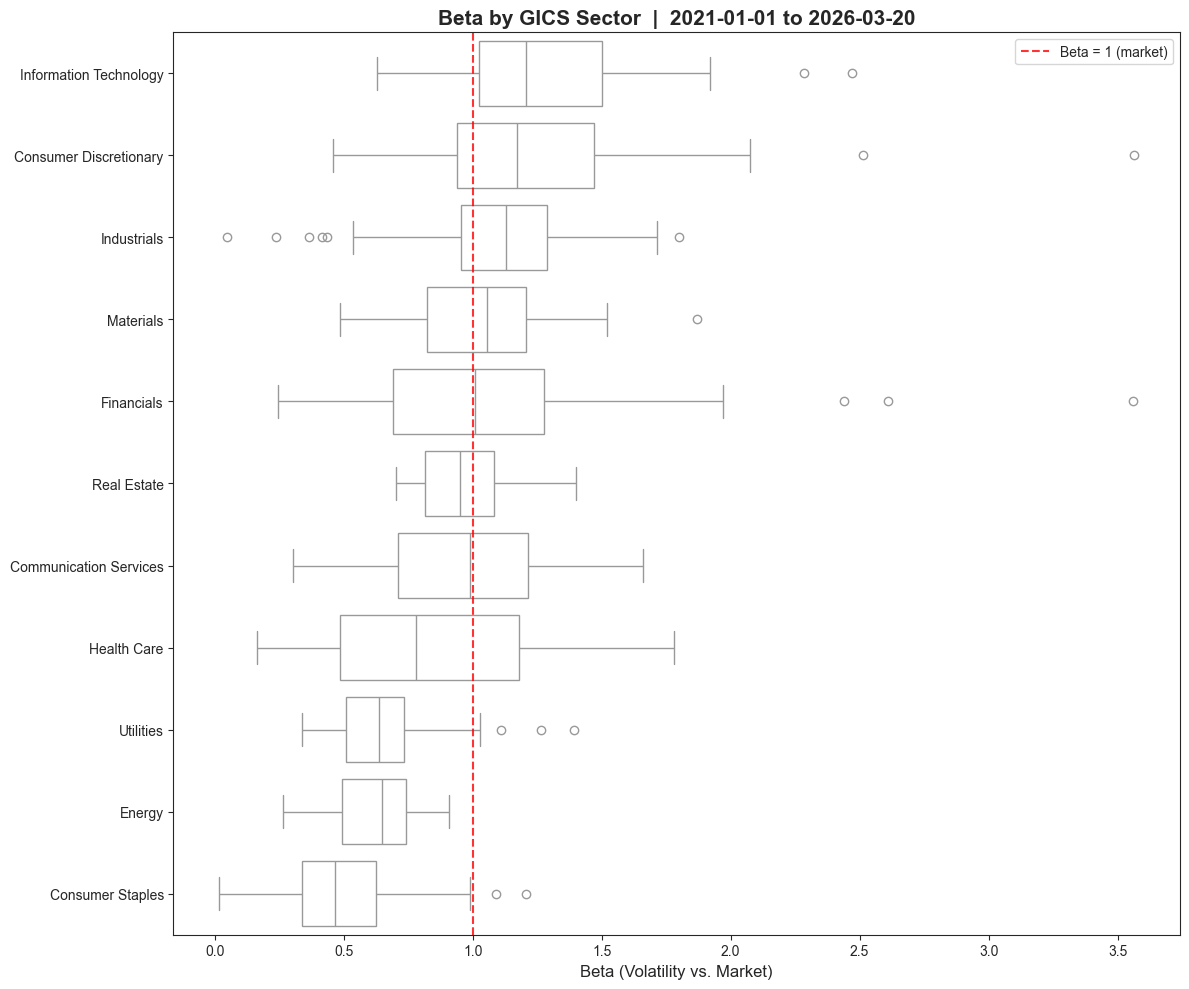

In [11]:
# Sort sectors by mean beta (descending) so the plot reads most→least volatile top→bottom
industry_order = (
    regression_results
    .groupby('industry')['Beta']
    .mean()
    .sort_values(ascending=False)  # highest mean beta at the top of the chart
    .index
)

sns.set_style('ticks')
fig, ax = plt.subplots(figsize=(12, 10))

sns.boxplot(
    data=regression_results,
    x='Beta',
    y='industry',
    order=industry_order,   # apply our sorted order
    color='white',          # clean black-and-white style (print-friendly)
    ax=ax
)

# Red dashed reference line at Beta = 1 (= the market itself)
ax.axvline(x=1, color='red', linestyle='--', alpha=0.8, label='Beta = 1 (market)')

ax.set_title(
    f"Beta by GICS Sector  |  {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}",
    fontsize=15, fontweight='bold'
)
ax.set_xlabel('Beta (Volatility vs. Market)', fontsize=12)
ax.set_ylabel('')   # sector names on the y-axis are self-explanatory; no label needed
ax.legend()
plt.tight_layout()
plt.show()


## 8. Summary Statistics by Sector

The table below aggregates beta across all stocks in each GICS sector.

| Column | Meaning |
|--------|---------|
| `count` | Number of S&P 500 stocks in that sector with a valid beta estimate |
| `mean` | Average beta for the sector — the sector's typical market sensitivity |
| `std` | Standard deviation of betas within the sector — high std means the sector contains a wide range of stock types |
| `min` / `max` | Most defensive and most aggressive stock in the sector |

Sorted by mean beta (highest first) — consistent with the boxplot order above.


In [13]:
print("--- Beta Summary by GICS Sector ---")

beta_summary = (
    regression_results
    .groupby('industry')['Beta']           # group rows by sector, focus on Beta column
    .agg(['count', 'mean', 'std', 'min', 'max'])  # compute five summary stats at once
    .sort_values('mean', ascending=False)  # highest mean beta sector at the top
    .round(2)                              # 2 decimal places for readability
)
display(beta_summary)


--- Beta Summary by GICS Sector ---


,count,mean,std,min,max
industry,,,,,
Information Technology,69,1.27,0.35,0.63,2.47
Consumer Discretionary,48,1.26,0.54,0.46,3.56
Industrials,77,1.09,0.33,0.05,1.80
Materials,26,1.05,0.33,0.49,1.87
Financials,75,1.05,0.54,0.24,3.56
Real Estate,31,0.98,0.21,0.70,1.40
Communication Services,23,0.96,0.38,0.31,1.66
Health Care,59,0.86,0.43,0.16,1.78
Utilities,31,0.67,0.24,0.34,1.39


## 9. Most and Least Volatile Stocks

Individual stock highlights — the 10 highest and 10 lowest beta names in the index.

**What to look for alongside Beta:**
- **R_Squared** — if a high-beta stock has a low R², most of its volatility is *idiosyncratic* (company-specific), not driven by the market. That's a different kind of risk.
- **Industry** — are the extremes concentrated in certain sectors, or spread across the index?

> 🛡️ Stocks with Beta < 1 (sometimes called **defensive stocks**) tend to hold up better during market downturns — historically Utilities, Consumer Staples, and Healthcare.


In [14]:
# ── Top 10 Highest Beta (most sensitive to market moves) ─────────────────────
print("--- Top 10 Highest Beta (Most Volatile) ---")
display(
    regression_results
    .nlargest(10, 'Beta')                          # select 10 rows with the largest Beta values
    [['Beta', 'R_Squared', 'industry']]            # show only relevant columns
    .round(3)
)

# ── Top 10 Lowest Beta (most defensive / market-insensitive) ──────────────────
print("\n--- Top 10 Lowest Beta (Most Defensive) ---")
display(
    regression_results
    .nsmallest(10, 'Beta')                         # select 10 rows with the smallest Beta values
    [['Beta', 'R_Squared', 'industry']]            # show only relevant columns
    .round(3)
)


--- Top 10 Highest Beta (Most Volatile) ---


,Beta,R_Squared,industry
Ticker,,,
CVNA,3.564,0.204,Consumer Discretionary
COIN,3.560,0.366,Financials
XYZ,2.610,0.500,Financials
CCL,2.515,0.360,Consumer Discretionary
APP,2.470,0.206,Information Technology
HOOD,2.438,0.262,Financials
NVDA,2.284,0.468,Information Technology
NCLH,2.076,0.290,Consumer Discretionary
KKR,1.972,0.535,Financials



--- Top 10 Lowest Beta (Most Defensive) ---


,Beta,R_Squared,industry
Ticker,,,
GIS,0.018,0.000,Consumer Staples
NOC,0.049,0.001,Industrials
CPB,0.067,0.002,Consumer Staples
CAG,0.067,0.002,Consumer Staples
KHC,0.124,0.008,Consumer Staples
BIIB,0.162,0.006,Health Care
HSY,0.189,0.016,Consumer Staples
LMT,0.237,0.020,Industrials
ALL,0.244,0.027,Financials


## 10. Beta Distribution — Histogram

A histogram shows the **full spread** of beta estimates across all ~500 stocks.

**What to look for:**
- Is the distribution roughly symmetric and centred near 1? (Expected — most stocks track the market closely)
- How wide is the spread? A wide distribution means the index contains very diverse risk profiles
- Are there many stocks with Beta > 2 or Beta < 0? (These are outliers worth examining individually)

The **KDE curve** (smooth line) is a kernel density estimate — a smoothed approximation of the distribution shape.


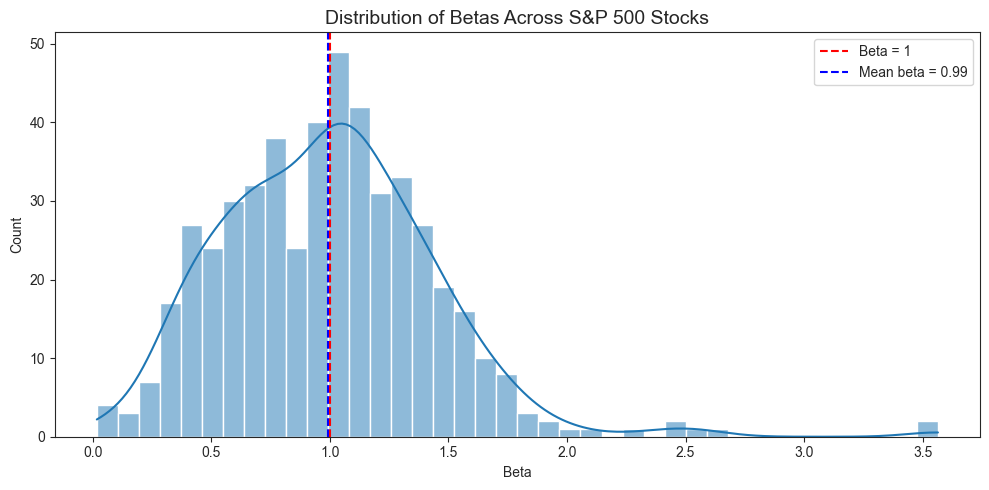

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

# bins=40 gives fine enough resolution to see the shape without too much noise
# kde=True overlays a smooth density curve on top of the histogram bars
sns.histplot(regression_results['Beta'], bins=40, kde=True, ax=ax)

# Red line: Beta = 1 (the market reference)
ax.axvline(1, color='red', linestyle='--', linewidth=1.5, label='Beta = 1')

# Blue line: the index-wide mean beta (typically close to 1 by construction)
ax.axvline(regression_results['Beta'].mean(), color='blue', linestyle='--',
           linewidth=1.5, label=f"Mean beta = {regression_results['Beta'].mean():.2f}")

ax.set_title('Distribution of Betas Across S&P 500 Stocks', fontsize=14)
ax.set_xlabel('Beta')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


## 11. Key Takeaways

After working through this notebook you should be able to:

1. **Explain beta** — it's the OLS slope when you regress a stock's returns on the market return.
2. **Interpret CAPM output** — alpha (excess return), beta (market sensitivity), R² (how much of the stock's variance the market explains).
3. **Collect and clean live financial data** — scraping Wikipedia, downloading from Yahoo Finance, converting daily prices to monthly returns.
4. **Scale a regression to 500+ assets** — using `.apply()` instead of a manual for-loop.
5. **Visualise distributions by group** — seaborn boxplots and histograms with reference lines.

---

### 🔭 Extensions to try
- **Rolling beta** — compute beta on a 36-month rolling window to see how it changes over time
- **Fama-French 3-factor model** — add size (SMB) and value (HML) factors alongside the market
- **Portfolio construction** — build a minimum-variance portfolio using estimated betas and covariances

### 📚 Further reading
- [CAPM — Investopedia](https://www.investopedia.com/terms/c/capm.asp)
- [yfinance documentation](https://ranaroussi.github.io/yfinance/)
- [statsmodels OLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html)
- [GICS Sector classification](https://www.msci.com/our-solutions/indexes/gics)
